## Requirements

In [16]:
import os
import numpy as np
import pandas as pd
import joblib

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import StrMethodFormatter

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader


In [17]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

Using device: cpu


## Reuse LSTM

In [18]:
class SequenceDataset(Dataset):
    """
    seq_len past steps -> predict the next step (one-step-ahead).
    """
    def __init__(self, X_array, y_array, seq_len: int):
        X_array = np.asarray(X_array, dtype=np.float32)
        y_array = np.asarray(y_array, dtype=np.float32).reshape(-1)

        assert X_array.ndim == 2
        assert y_array.ndim == 1
        assert len(X_array) == len(y_array)

        self.X = X_array
        self.y = y_array
        self.seq_len = int(seq_len)

        self.length = len(self.y) - self.seq_len
        if self.length <= 0:
            raise ValueError(f"seq_len={seq_len} is longer than series length={len(self.y)}")

    def __len__(self):
        return self.length

    def __getitem__(self, idx: int):
        x_seq = self.X[idx : idx + self.seq_len]       
        y_t   = self.y[idx + self.seq_len]           
        return torch.from_numpy(x_seq), torch.tensor(y_t, dtype=torch.float32)

def make_loader(X, y, seq_len: int, batch_size: int, shuffle: bool = False):
    ds = SequenceDataset(X, y, seq_len)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, drop_last=False)

class LSTMRegressor(nn.Module):
    """
    One-step-ahead LSTM regressor:
      input:  (batch, seq_len, n_features)
      output: (batch,)  predicted price (scaled)
    """
    def __init__(self, n_features: int,
                 hidden_size: int = 64,
                 num_layers: int = 2,
                 dropout: float = 0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=n_features,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, (h_n, c_n) = self.lstm(x)        
        last_hidden = out[:, -1, :]           
        y_pred = self.fc(last_hidden)         
        return y_pred.squeeze(-1)             


## Data Splitting

In [19]:
df = pd.read_csv(
    "./data/processed/rfe_dataset_2019_2025.csv",
    parse_dates=["datetime"],
    index_col="datetime",
)

datetime_index = pd.to_datetime(df.index, utc=True)

y_all = df["price"].astype(float)
X_all = df.drop(columns=["price"]).astype(float)

N = len(df)
n_test = int(np.ceil(0.10 * N))
n_trainval = N - n_test

X_trainval = X_all.iloc[:n_trainval].copy()
y_trainval = y_all.iloc[:n_trainval].copy()
X_test     = X_all.iloc[n_trainval:].copy()
y_test     = y_all.iloc[n_trainval:].copy()

print(f"Total samples: {N}")
print(f"Train+Val: {len(X_trainval)}  Test: {len(X_test)}")


x_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()

X_trainval_scaled = x_scaler.fit_transform(X_trainval)
y_trainval_scaled = y_scaler.fit_transform(
    y_trainval.to_numpy().reshape(-1, 1)
).reshape(-1)

X_test_scaled = x_scaler.transform(X_test)
y_test_scaled = y_scaler.transform(
    y_test.to_numpy().reshape(-1, 1)
).reshape(-1)

print("Scaled shapes:")
print("  X_trainval:", X_trainval_scaled.shape,
      " y_trainval:", y_trainval_scaled.shape)
print("  X_test:    ", X_test_scaled.shape,
      " y_test:    ", y_test_scaled.shape)

Total samples: 52560
Train+Val: 47304  Test: 5256
Scaled shapes:
  X_trainval: (47304, 29)  y_trainval: (47304,)
  X_test:     (5256, 29)  y_test:     (5256,)


## Build TEST + CONTEXT (train tail) for LSTM (one-step ahead)

In [20]:
SEQ_LEN = 24

def create_test_with_context_scaled(
    X_trainval_scaled, y_trainval_scaled,
    X_test_scaled,      y_test_scaled,
    seq_len: int,
):
    """
    Take last `seq_len` rows from trainval and stack the entire test set after them.
    Then SequenceDataset with seq_len will create exactly len(test) samples:
       - each sample has 24 hours of history (some from tail, some from test)
       - target is the corresponding test point.
    """
    X_tail = X_trainval_scaled[-seq_len:]          
    y_tail = y_trainval_scaled[-seq_len:]          

    X_ctx = np.vstack([X_tail, X_test_scaled])     
    y_ctx = np.concatenate([y_tail, y_test_scaled])  

    return X_ctx, y_ctx

X_test_ctx_scaled, y_test_ctx_scaled = create_test_with_context_scaled(
    X_trainval_scaled, y_trainval_scaled,
    X_test_scaled,      y_test_scaled,
    seq_len=SEQ_LEN,
)

print("Context+test shapes:",
      X_test_ctx_scaled.shape, y_test_ctx_scaled.shape)

# DataLoader for test+context
BATCH_SIZE = 128  
test_loader = make_loader(
    X_test_ctx_scaled,
    y_test_ctx_scaled,
    seq_len=SEQ_LEN,
    batch_size=BATCH_SIZE,
    shuffle=False,
)


Context+test shapes: (5280, 29) (5280,)


In [21]:
state_dict = torch.load(
    "./models/lstm_5years_model.pth",
    map_location=DEVICE,
)

n_features = X_trainval.shape[1]

w_ih_l0 = state_dict["lstm.weight_ih_l0"]
hidden_size_inferred = w_ih_l0.shape[0] // 4

num_layers_inferred = 0
while f"lstm.weight_ih_l{num_layers_inferred}" in state_dict:
    num_layers_inferred += 1

print(f"Inferred hidden_size: {hidden_size_inferred}")
print(f"Inferred num_layers:  {num_layers_inferred}")

lstm = LSTMRegressor(
    n_features=n_features,
    hidden_size=hidden_size_inferred,
    num_layers=num_layers_inferred,
    dropout=0.0,
).to(DEVICE)

lstm.load_state_dict(state_dict)
lstm.eval()

Inferred hidden_size: 64
Inferred num_layers:  1


LSTMRegressor(
  (lstm): LSTM(29, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)

## Model Predictions

In [22]:
# Run predictions on test+context (24 hours)
preds_scaled = []
actuals_scaled = []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(DEVICE)         
        yb = yb.to(DEVICE)          
        out = lstm(xb)              
        preds_scaled.extend(out.cpu().numpy().flatten())
        actuals_scaled.extend(yb.cpu().numpy().flatten())

preds_scaled = np.array(preds_scaled)      
actuals_scaled = np.array(actuals_scaled) 

assert len(preds_scaled) == len(y_test_scaled)

# Inverse transform back to real prices and compute RMSE
y_pred_inv = y_scaler.inverse_transform(
    preds_scaled.reshape(-1, 1)
).flatten()
y_true_inv = y_scaler.inverse_transform(
    y_test_scaled.reshape(-1, 1)
).flatten()

rmse = np.sqrt(mean_squared_error(y_true_inv, y_pred_inv))
print(f"\n LSTM Test RMSE (with train context): {rmse:.4f}")


 LSTM Test RMSE (with train context): 56.6520


## LSTM Predictions

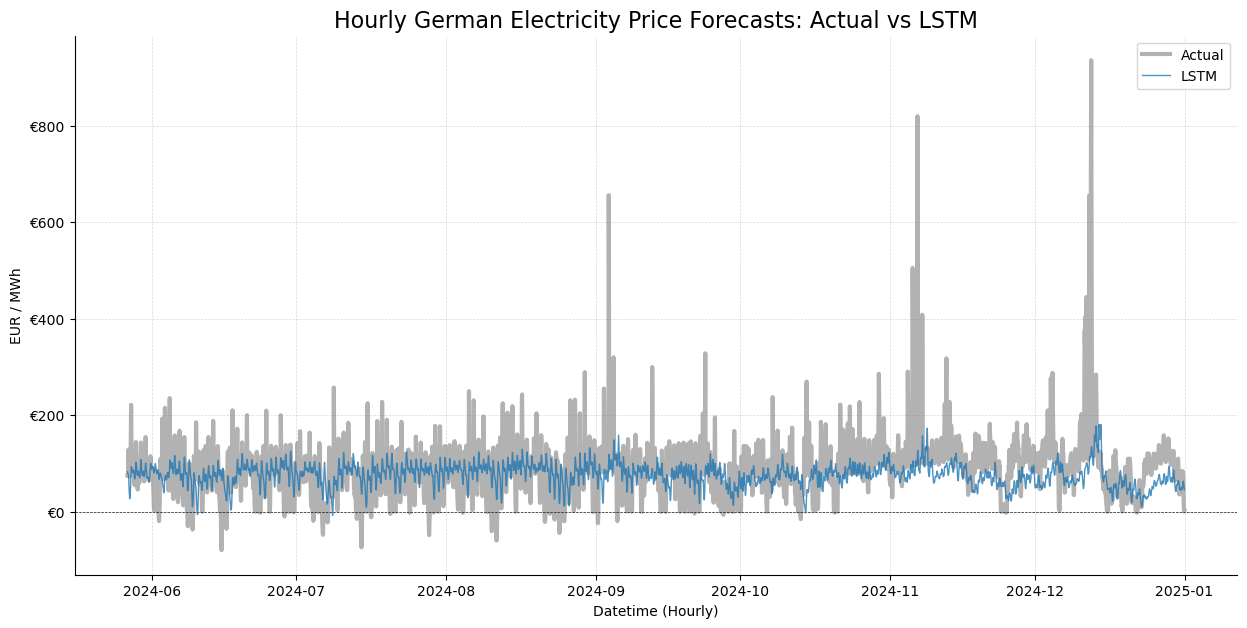

In [23]:
test_datetime = datetime_index[-len(y_test):]

fig, ax = plt.subplots(figsize=(15, 7))
ax.plot(test_datetime, y_true_inv, color="black", linewidth=3, alpha=0.3,
        label="Actual", zorder=1)
ax.plot(test_datetime, y_pred_inv, color="tab:blue", linewidth=1.0, alpha=0.8,
        label="LSTM", zorder=2)

ax.axhline(0, color="black", linewidth=0.5, linestyle="--", zorder=0)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.yaxis.set_major_formatter(StrMethodFormatter("€{x:,.0f}"))
ax.grid(which="major", linestyle="--", linewidth=0.5, alpha=0.3, color="gray")

ax.legend()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_xlabel("Datetime (Hourly)")
ax.set_ylabel("EUR / MWh")
ax.set_title("Hourly German Electricity Price Forecasts: Actual vs LSTM", fontsize=16)
plt.show()

## Construct cumulative metric functions 

In [24]:

# Cumulative metric functions 
def cum_rmse(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    se = (y_true - y_pred) ** 2
    cum_se = np.cumsum(se)
    n = np.arange(1, len(y_true) + 1)
    return np.sqrt(cum_se / n)

def cum_mae(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    ae = np.abs(y_true - y_pred)
    cum_ae = np.cumsum(ae)
    n = np.arange(1, len(y_true) + 1)
    return cum_ae / n

def cum_nrmse(y_true, y_pred):
    y_true = np.asarray(y_true)
    rng = y_true.max() - y_true.min()
    rng = rng if rng != 0 else 1.0
    return cum_rmse(y_true, y_pred) / rng

def cum_rmae(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    ae = np.abs(y_true - y_pred)
    cum_ae = np.cumsum(ae)
    abs_y = np.abs(y_true)
    cum_abs_y = np.cumsum(abs_y)
    n = np.arange(1, len(y_true) + 1)
    denom = cum_abs_y / n
    denom[denom == 0] = 1.0
    return (cum_ae / n) / denom

def cum_smape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    num = 2.0 * np.abs(y_true - y_pred)
    denom = np.abs(y_true) + np.abs(y_pred)
    denom[denom == 0] = 1.0
    s = num / denom
    cum_s = np.cumsum(s)
    n = np.arange(1, len(y_true) + 1)
    return cum_s / n

# def cum_apb(y_true, y_pred):
#     y_true = np.asarray(y_true)
#     y_pred = np.asarray(y_pred)
#     cum_y_true = np.cumsum(y_true)
#     cum_y_pred = np.cumsum(y_pred)
#     n = np.arange(1, len(y_true) + 1)
#     mean_true = cum_y_true / n
#     mean_pred = cum_y_pred / n
#     denom = np.where(mean_true == 0, 1.0, mean_true)
#     return np.abs(mean_pred - mean_true) / denom

def cum_apb(y_true, y_pred):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    global_sum = np.sum(y_true)
    cum_num = np.cumsum(y_true - y_pred)
    if global_sum == 0:
        return np.full_like(cum_num, np.nan, dtype=float)
    return np.abs(cum_num / global_sum)


def cum_tic(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    se = (y_true - y_pred) ** 2
    y2 = y_true ** 2
    p2 = y_pred ** 2
    cum_se = np.cumsum(se)
    cum_y2 = np.cumsum(y2)
    cum_p2 = np.cumsum(p2)
    num = np.sqrt(cum_se)
    denom = np.sqrt(cum_y2) + np.sqrt(cum_p2)
    denom[denom == 0] = 1.0
    return num / denom

# Compute cumulative metric series
rmse_series  = cum_rmse(y_true_inv, y_pred_inv)
mae_series   = cum_mae(y_true_inv, y_pred_inv)
nrmse_series = cum_nrmse(y_true_inv, y_pred_inv)
rmae_series  = cum_rmae(y_true_inv, y_pred_inv)
smape_series = cum_smape(y_true_inv, y_pred_inv)
tic_series   = cum_tic(y_true_inv, y_pred_inv)
apb_series   = cum_apb(y_true_inv, y_pred_inv)

metric_series = {
    "RMSE":  rmse_series,
    "MAE":   mae_series,
    "NRMSE": nrmse_series,
    "RMAPE": rmae_series,
    "SMAPE": smape_series,
    "TIC":   tic_series,
    "APB":   apb_series,
}




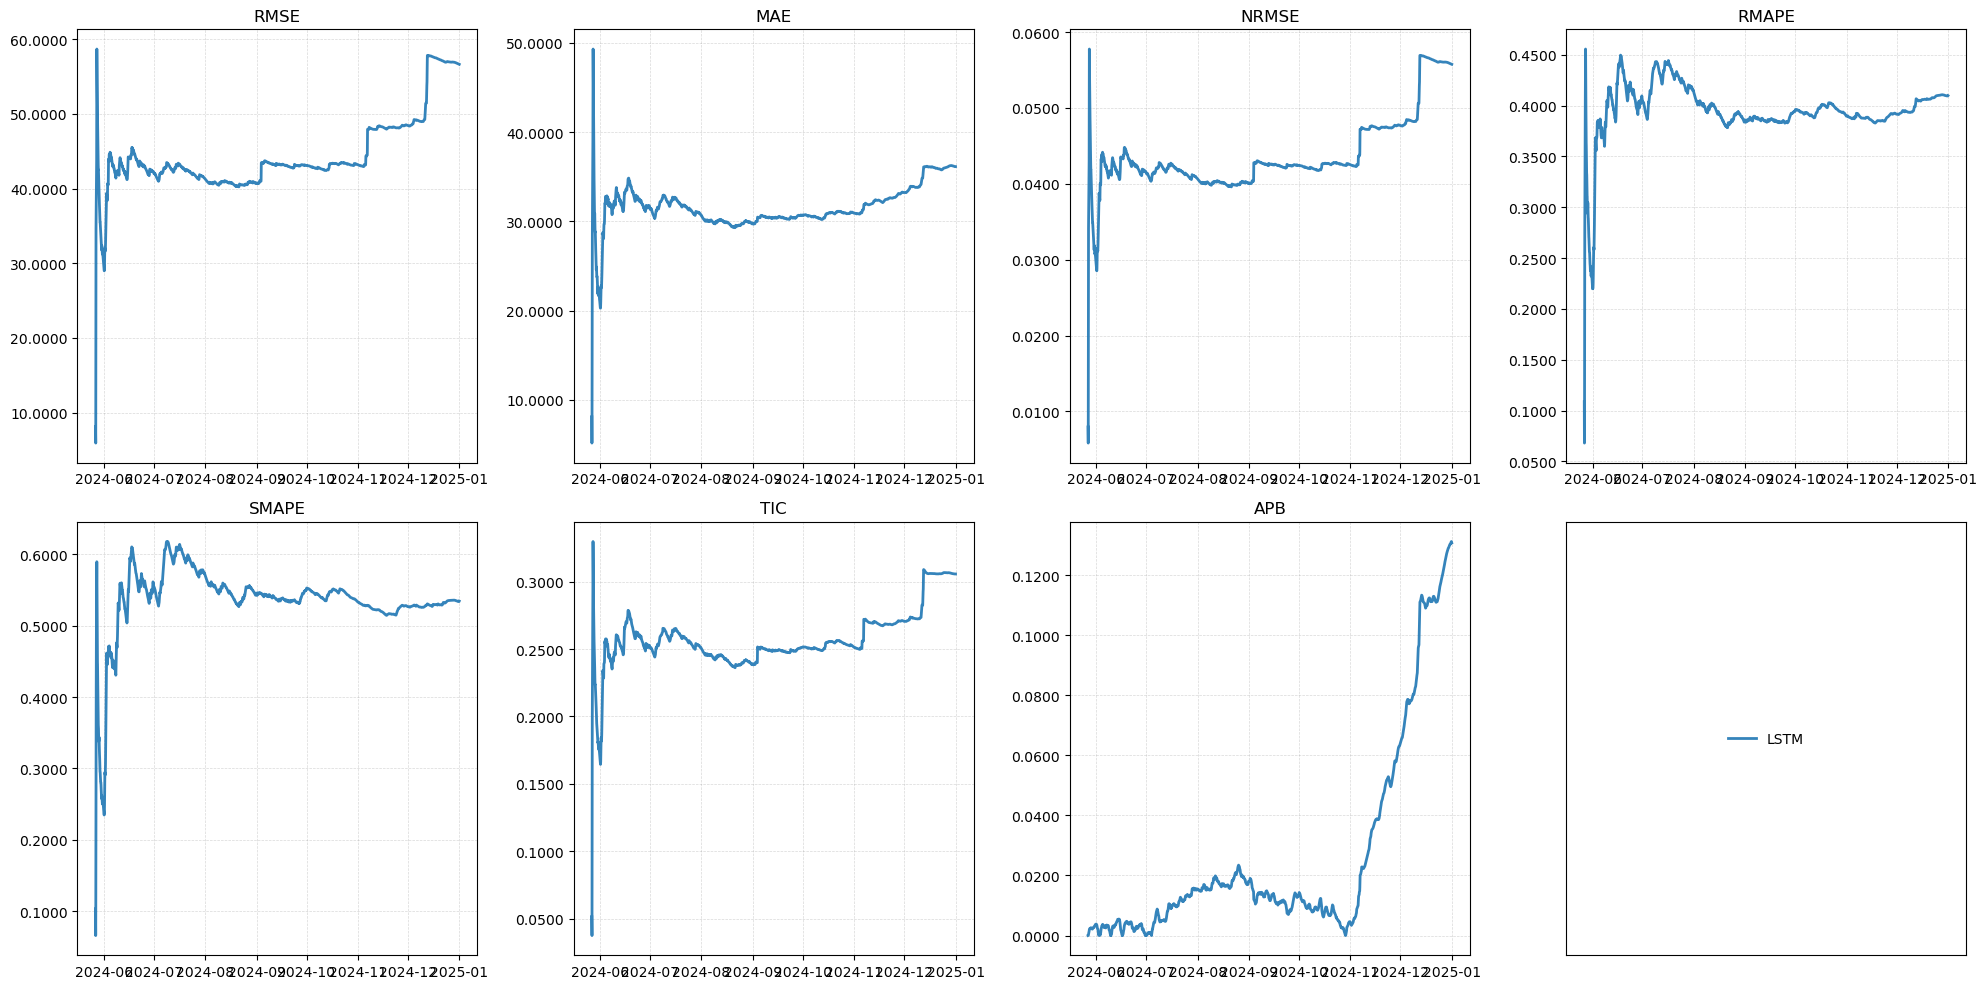

In [25]:
# Plot metrics
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(20, 10))
axes = axes.flatten()

test_datetime = datetime_index[-len(y_test):]

metric_names = list(metric_series.keys())
for i, mname in enumerate(metric_names):
    ax = axes[i]
    series = metric_series[mname]
    ax.plot(test_datetime, series, color="tab:blue", linewidth=2, alpha=0.9, label="LSTM")

    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    ax.yaxis.set_major_formatter(StrMethodFormatter("{x:,.4f}"))
    ax.grid(which="major", linestyle="--", linewidth=0.5, alpha=0.3, color="gray")
    ax.set_title(mname)

axes[-1].axis("off")
legend_ax = axes[-1]
legend_ax.clear()
legend_ax.set_xticks([])
legend_ax.set_yticks([])
legend_ax.set_frame_on(True)
for spine in legend_ax.spines.values():
    spine.set_visible(True)

handles, labels = axes[0].get_legend_handles_labels()
legend_ax.legend(handles, labels, loc="center", frameon=False,
                 bbox_to_anchor=(0.5, 0.5),
                 bbox_transform=legend_ax.transAxes)

fig.tight_layout()
plt.show()

## Save

In [26]:
# Save in data_predictions
os.makedirs("./data/predictions", exist_ok=True)
joblib.dump(y_true_inv, "./data/predictions/y_test.pkl")
joblib.dump(y_pred_inv, "./data/predictions/lstm_y_test_pred.pkl")

['./data/predictions/lstm_y_test_pred.pkl']